In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

path = "/content/drive/MyDrive/TEMPORAL DRIFT ANALYSIS/1429_1.csv"
df = pd.read_csv(path)

df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  object 
 1   name                  27900 non-null  object 
 2   asins                 34658 non-null  object 
 3   brand                 34660 non-null  object 
 4   categories            34660 non-null  object 
 5   keys                  34660 non-null  object 
 6   manufacturer          34660 non-null  object 
 7   reviews.date          34621 non-null  object 
 8   reviews.dateAdded     24039 non-null  object 
 9   reviews.dateSeen      34660 non-null  object 
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float64
 14  reviews.rating        34627 non-null  float64
 15  reviews.sourceURLs 

/tmp/ipykernel_767/446374526.py:4: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [3]:
df = df[['reviews.text','reviews.rating','reviews.date','asins']]

df = df.rename(columns={
    'reviews.text':'review',
    'reviews.rating':'rating',
    'reviews.date':'date',
    'asins':'product_id'
})

In [4]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['month'] = df['date'].dt.to_period('M')

/tmp/ipykernel_767/211738779.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['date'].dt.to_period('M')


In [5]:
df[['review','month']].head()

,review,month
0,This product so far has not disappointed. My c...,2017-01
1,great for beginner or experienced person. Boug...,2017-01
2,Inexpensive tablet for him to use and learn on...,2017-01
3,I've had my Fire HD 8 two weeks now and I love...,2017-01
4,I bought this for my grand daughter when she c...,2017-01


In [6]:
df = df.dropna(subset=['review'])

In [7]:
import re

def clean_text(text):

    text = text.lower()
    text = re.sub(r"http\S+","",text)
    text = re.sub(r"[^a-zA-Z\s]","",text)

    return text

df['clean_review'] = df['review'].apply(clean_text)

In [8]:
df[['review','clean_review']].head()

,review,clean_review
0,This product so far has not disappointed. My c...,this product so far has not disappointed my ch...
1,great for beginner or experienced person. Boug...,great for beginner or experienced person bough...
2,Inexpensive tablet for him to use and learn on...,inexpensive tablet for him to use and learn on...
3,I've had my Fire HD 8 two weeks now and I love...,ive had my fire hd two weeks now and i love i...
4,I bought this for my grand daughter when she c...,i bought this for my grand daughter when she c...


**Phase** **2**

In [9]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 131.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [10]:
import spacy

nlp = spacy.load("en_core_web_sm")

In [11]:
def extract_aspects(text):

    doc = nlp(text)

    aspects = []

    for chunk in doc.noun_chunks:

        aspect = chunk.text.lower().strip()

        if len(aspect) > 3:
            aspects.append(aspect)

    return aspects

In [12]:
sample_df = df.sample(5000, random_state=42)

sample_df['aspects'] = sample_df['clean_review'].apply(extract_aspects)

In [13]:
sample_df = sample_df[sample_df['aspects'].map(len) > 0]

In [14]:
sample_df = sample_df.explode('aspects')

In [15]:
# normalize aspects
sample_df['aspects'] = sample_df['aspects'].str.lower().str.strip()

# remove articles
sample_df['aspects'] = sample_df['aspects'].str.replace(r'^(the|this|a|an)\s+', '', regex=True)

# remove very short terms
sample_df = sample_df[sample_df['aspects'].str.len() > 3]

# remove pronouns / meaningless terms
remove_terms = [
    "this","that","they","them","what","which",
    "something","anything","everything","someone",
    "one","some","lot","thing",
    "everything","nothing","anything"
]

sample_df = sample_df[~sample_df['aspects'].isin(remove_terms)]

In [16]:
remove_context_words = [
    "kids","son","wife","gift","people","family",
    "my son","my kids","my wife"
]

sample_df = sample_df[~sample_df['aspects'].isin(remove_context_words)]

In [17]:
remove_generic = [
    "product","device","thing","stuff","everything"
]

sample_df = sample_df[~sample_df['aspects'].isin(remove_generic)]

In [18]:
remove_noise = [
    "these",
    "christmas",
    "money",
    "time",
    "anyone",
    "someone",
    "something",
    "everything",
    "great product",
    "great tablet",
    "my daughter",
    "my son",
    "my kids",
    "my wife"
]

sample_df = sample_df[~sample_df['aspects'].isin(remove_noise)]

In [19]:
sample_df = sample_df[~sample_df['aspects'].str.startswith("my ")]

In [20]:
# remove long noun phrases
sample_df = sample_df[sample_df['aspects'].str.split().str.len() <= 2]

In [21]:
sample_df = sample_df[sample_df['aspects'].str.split().str.len() <= 3]

aspect_counts = sample_df['aspects'].value_counts()

valid_aspects = aspect_counts[aspect_counts > 30].index

sample_df = sample_df[sample_df['aspects'].isin(valid_aspects)]

In [22]:
sample_df['aspects'].value_counts().head(20)

,count
aspects,
tablet,574
price,286
amazon,216
kindle,214
echo,211
music,205
books,199
games,155
apps,131


**PHASE 3**

In [23]:
!pip install transformers torch tqdm

In [24]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm

In [25]:
df = pd.read_csv("/content/drive/MyDrive/TEMPORAL DRIFT ANALYSIS/1429_1.csv")
df.head()

/tmp/ipykernel_767/425359503.py:1: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/TEMPORAL DRIFT ANALYSIS/1429_1.csv")


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [26]:
import pandas as pd

path = "/content/drive/MyDrive/TEMPORAL DRIFT ANALYSIS/1429_1.csv"
df = pd.read_csv(path)

df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  object 
 1   name                  27900 non-null  object 
 2   asins                 34658 non-null  object 
 3   brand                 34660 non-null  object 
 4   categories            34660 non-null  object 
 5   keys                  34660 non-null  object 
 6   manufacturer          34660 non-null  object 
 7   reviews.date          34621 non-null  object 
 8   reviews.dateAdded     24039 non-null  object 
 9   reviews.dateSeen      34660 non-null  object 
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float64
 14  reviews.rating        34627 non-null  float64
 15  reviews.sourceURLs 

/tmp/ipykernel_767/446374526.py:4: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [27]:
MODEL_NAME = "nlptown/bert-base-multilingual-uncased-sentiment"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(105879, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [28]:
print(df.columns)

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.userCity',
       'reviews.userProvince', 'reviews.username'],
      dtype='object')


In [29]:
df["reviewText"] = df["reviews.text"]

In [30]:
df["reviewText"] = df["reviewText"].fillna("")
df["aspect"] = df["reviewText"].apply(extract_aspects)

In [31]:
df['aspect'] = df['aspect'].apply(lambda x: x if isinstance(x, list) else [])
print(len(df))
# df = df[df['aspect'].map(len) > 0]


34660


In [32]:
df = df[df['aspect'].map(len) > 0]

In [33]:
df["aspect"].head(10)

,aspect
0,"[this product, my children, the ability, contr..."
1,"[beginner, experienced person, a gift]"
2,"[inexpensive tablet, the nabi]"
3,"[my fire hd, this tablet, a great value, prime..."
4,"[this, my grand daughter, the user, her age, n..."
5,"[this amazon fire, 8 inch tablet, the perfect ..."
6,"[reading, the go, nice and light weight, the p..."
7,"[this, a christmas gift, my inlaws, husband, u..."
8,"[a device, books, that, my borrowed library, b..."
9,"[books, them, the reader]"


In [34]:
df = df.explode("aspect")

In [35]:
df["aspect_text"] = df["aspect"] + " : " + df["reviewText"]

In [36]:
def predict_sentiment(texts, batch_size=32):

    all_scores = []

    for i in tqdm(range(0, len(texts), batch_size)):

        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128, # yahan raat ko change kiya tha
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)

        preds = torch.argmax(probs, dim=1)

        scores = preds.cpu().numpy() + 1   # convert 0-4 → 1-5 stars
        all_scores.extend(scores)

    return all_scores

In [37]:
# texts = df["aspect_text"].tolist()

In [38]:
# df["sentiment_score"] = predict_sentiment(texts)

In [39]:
texts = df["aspect_text"].tolist()

df["sentiment_score"] = predict_sentiment(texts, batch_size=128) # yahan bhi 256 se 128

100%|██████████| 1638/1638 [25:05<00:00,  1.09it/s]


In [40]:
df["aspect"] = df["aspect"].str.lower().str.strip()


In [41]:
bad_aspects = [
    "this", "that", "they", "it", "we", "you",
    "thing", "time", "lot", "way", "people",
    "someone", "something", "product", "stuff"
]

df = df[~df["aspect"].isin(bad_aspects)]


In [42]:
df = df[df["aspect"].str.len() > 2]


In [43]:
top_aspects = df["aspect"].value_counts().head(20).index

df = df[df["aspect"].isin(top_aspects)]

In [44]:
df["aspect"].value_counts().head(20)

,count
aspect,
this tablet,2149
the price,1917
them,1846
alexa,1824
what,1813
music,1683
books,1469
amazon,1465
which,1187


In [45]:
df["aspect"] = df["aspect"].apply(lambda x: x.split()[-1])

In [46]:
bad_words = [
    "thing","something","everything","lot","which","what",
    "them","they","someone","son","kids","gift"
]

df = df[~df["aspect"].isin(bad_words)]


In [47]:
df["aspect"].value_counts().head(20)

,count
aspect,
tablet,3003
price,1917
alexa,1824
music,1683
books,1469
amazon,1465
games,1176
product,1074
echo,1055


In [48]:
remove_words = ["product", "amazon"]

df = df[~df["aspect"].isin(remove_words)]

In [49]:
df["aspect"].value_counts().head(20)

,count
aspect,
tablet,3003
price,1917
alexa,1824
music,1683
books,1469
games,1176
echo,1055
movies,901
apps,757


In [50]:
df[["aspect","sentiment_score"]].head(10)

,aspect,sentiment_score
3,tablet,5
3,tablet,5
3,movies,5
4,price,4
4,tablet,5
8,books,5
8,books,5
8,books,5
9,books,5
11,movies,5


In [51]:
df["sentiment_score"].value_counts()

,count
sentiment_score,
5,8261
4,3790
3,1172
2,339
1,223


In [52]:
df["reviews.date"] = pd.to_datetime(df["reviews.date"], errors="coerce")
df["reviews.date"] = df["reviews.date"].dt.strftime("%d-%m-%Y")
df["month"] = pd.to_datetime(df["reviews.date"], errors="coerce").dt.to_period("M")

/tmp/ipykernel_767/3111585585.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["month"] = pd.to_datetime(df["reviews.date"], errors="coerce").dt.to_period("M")


In [53]:
df[["reviews.date","month"]].head(10)

,reviews.date,month
3,13-01-2017,2017-01
3,13-01-2017,2017-01
3,13-01-2017,2017-01
4,12-01-2017,2017-01
4,12-01-2017,2017-01
8,23-01-2017,2017-01
8,23-01-2017,2017-01
8,23-01-2017,2017-01
9,23-01-2017,2017-01
11,23-01-2017,2017-01


In [54]:
aspect_month_sentiment = (
    df.groupby(["month", "aspect"])["sentiment_score"]
    .mean()
    .reset_index()
)

In [55]:
aspect_month_sentiment.head(10)

,month,aspect,sentiment_score
0,2014-10,books,3.333333
1,2014-11,books,4.500000
2,2014-11,price,3.333333
3,2015-01,books,5.000000
4,2015-01,price,4.000000
5,2015-03,books,4.500000
6,2015-04,books,5.000000
7,2015-04,price,4.000000
8,2015-05,books,5.000000
9,2015-07,books,4.625000


In [56]:
pivot_table = aspect_month_sentiment.pivot(
    index="month",
    columns="aspect",
    values="sentiment_score"
)


In [57]:
pivot_table.head()

aspect,alexa,apps,books,echo,games,movies,music,price,tablet
month,,,,,,,,,
2014-10,NaN,NaN,3.333333,NaN,NaN,NaN,NaN,NaN,NaN
2014-11,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,3.333333,NaN
2015-01,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,4.000000,NaN
2015-03,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN
2015-04,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,4.000000,NaN


In [58]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=pivot_table)

https://docs.google.com/spreadsheets/d/1aHq29xxU6pGoocqZjmxsisd7ikmJt1u3ZgByEW_zjcY/edit#gid=0


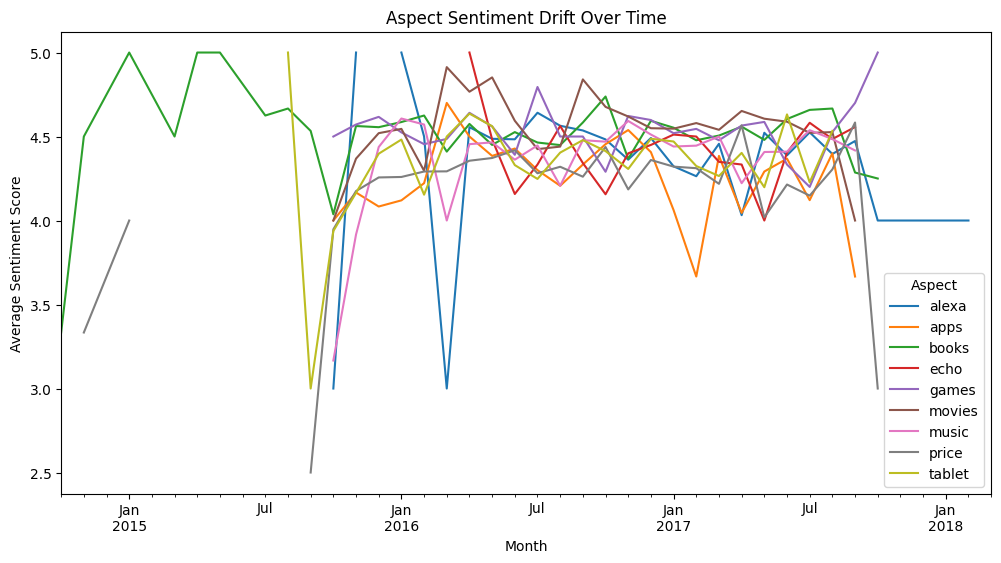

In [59]:
import matplotlib.pyplot as plt

pivot_table.plot(figsize=(12,6))

plt.title("Aspect Sentiment Drift Over Time")
plt.xlabel("Month")
plt.ylabel("Average Sentiment Score")
plt.legend(title="Aspect")
plt.show()

<Axes: xlabel='month'>

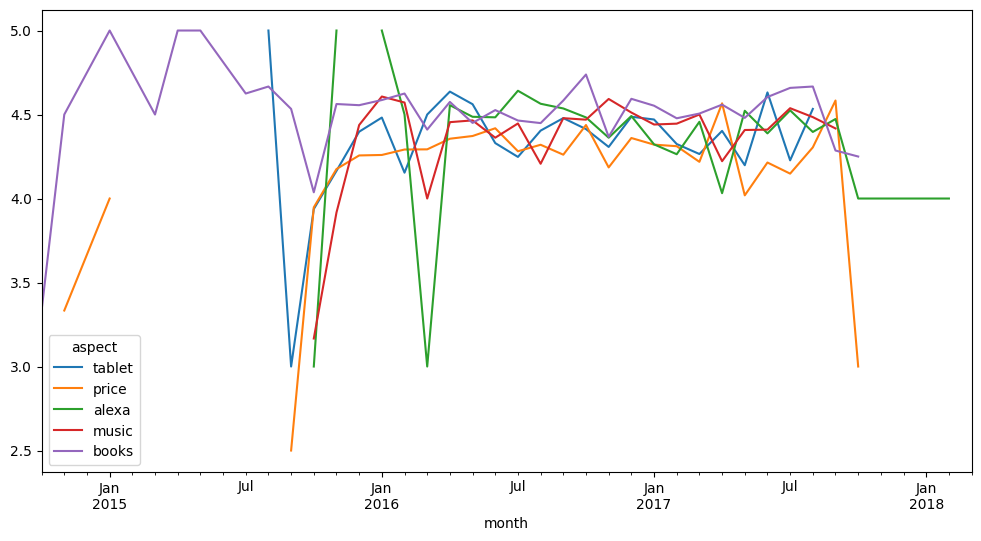

In [60]:
top_aspects = df["aspect"].value_counts().head(5).index
filtered = pivot_table[top_aspects]

filtered.plot(figsize=(12,6))

In [61]:
pivot_table = pivot_table.sort_index()

<Axes: xlabel='month'>

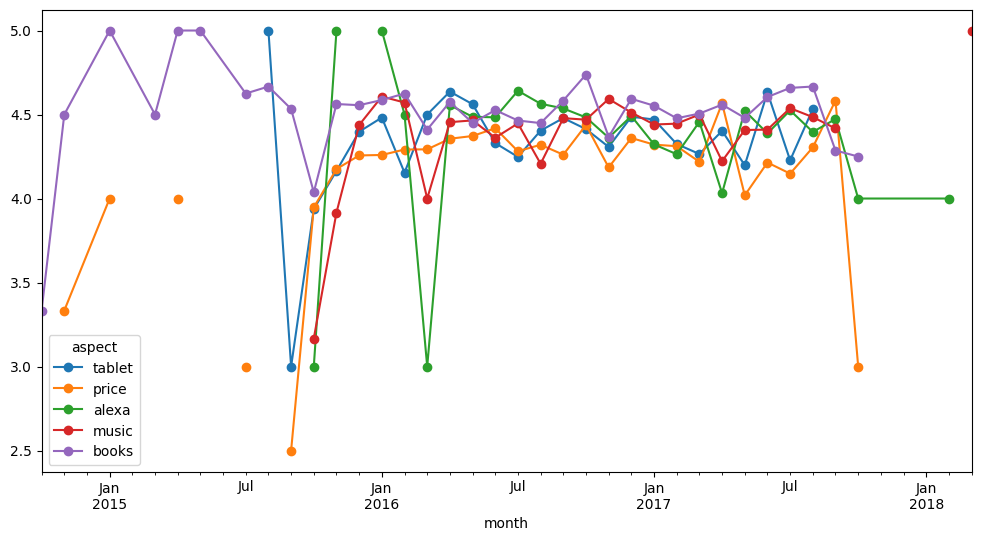

In [62]:
filtered.plot(figsize=(12,6), marker='o')

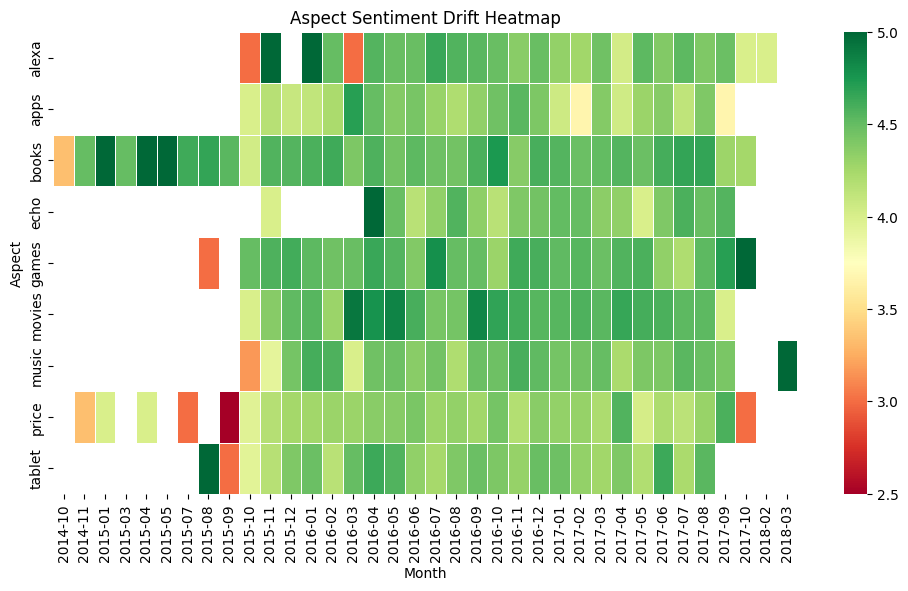

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot_table.T,
    cmap="RdYlGn",
    annot=False,
    linewidths=0.5
)

plt.title("Aspect Sentiment Drift Heatmap")
plt.xlabel("Month")
plt.ylabel("Aspect")

plt.show()

In [64]:
rolling_mean = pivot_table.rolling(window=3).mean()

drift_ma = pivot_table - rolling_mean

drift_ma.head()

aspect,alexa,apps,books,echo,games,movies,music,price,tablet
month,,,,,,,,,
2014-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01,NaN,NaN,0.722222,NaN,NaN,NaN,NaN,NaN,NaN
2015-03,NaN,NaN,-0.166667,NaN,NaN,NaN,NaN,NaN,NaN
2015-04,NaN,NaN,0.166667,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
drift_flag = drift_ma.abs() > 0.5
drift_flag.sum()

,0
aspect,
alexa,2
apps,0
books,1
echo,0
games,0
movies,0
music,1
price,2
tablet,0


In [66]:
drift_score = drift_ma.abs().mean()

drift_score.sort_values(ascending=False)

,0
aspect,
alexa,0.182607
apps,0.134481
price,0.134293
tablet,0.125955
echo,0.124218
books,0.121708
music,0.119410
movies,0.105081
games,0.103113


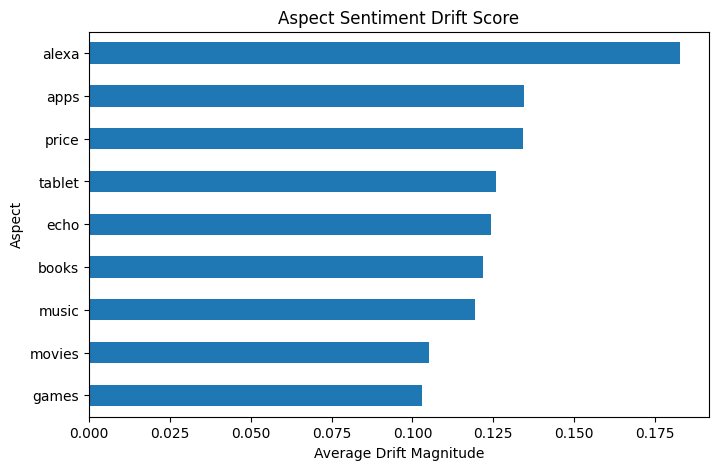

In [67]:
drift_score.sort_values().plot(kind="barh", figsize=(8,5))

plt.title("Aspect Sentiment Drift Score")
plt.xlabel("Average Drift Magnitude")
plt.ylabel("Aspect")

plt.show()

**Phase 5**

In [68]:
df["time_index"] = df["month"].astype("category").cat.codes

In [69]:
from transformers import AutoTokenizer, AutoModel
import torch

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [70]:
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    with torch.no_grad():
        outputs = model(**inputs)

    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

In [73]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def get_embeddings_batch(texts, batch_size=128):

    all_embeddings = []

    for i in range(0, len(texts), batch_size):

        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            padding=True
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        batch_embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()

        all_embeddings.extend(batch_embeddings)

    return all_embeddings

In [74]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [75]:
df_sample = df.sample(3000, random_state=42)

In [78]:
texts = df_sample["aspect_text"].tolist()

embeddings = get_embeddings_batch(texts, batch_size=128)

In [79]:
import numpy as np

X_text = np.vstack(embeddings)

X_time = df_sample["time_index"].values.reshape(-1,1)

X = np.hstack([X_text, X_time])

In [80]:
y = df_sample["sentiment_score"].values

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [102]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [103]:
model_temporal = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42
)
model_temporal.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_split=5, n_estimators=300, random_state=42)

In [104]:
from sklearn.metrics import classification_report

y_pred = model_temporal.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        11
           2       1.00      0.18      0.30        17
           3       1.00      0.20      0.33        45
           4       0.64      0.37      0.46       178
           5       0.70      0.97      0.81       349

    accuracy                           0.69       600
   macro avg       0.67      0.34      0.38       600
weighted avg       0.70      0.69      0.64       600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


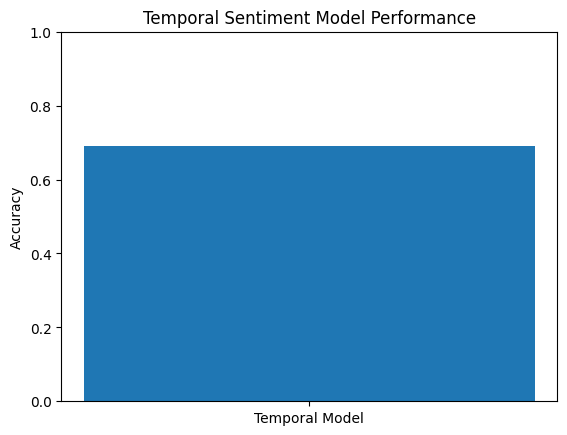

In [105]:
import matplotlib.pyplot as plt

accuracy = model_temporal.score(X_test, y_test)

plt.bar(["Temporal Model"], [accuracy])
plt.ylabel("Accuracy")
plt.title("Temporal Sentiment Model Performance")
plt.ylim(0,1)

plt.show()



**PHASE 6**



In [106]:
drift_score = drift_ma.abs().mean()

In [107]:
drift_df = drift_score.reset_index()
drift_df.columns = ["aspect", "drift_score"]

drift_df.sort_values(by="drift_score", ascending=False)

,aspect,drift_score
0,alexa,0.182607
1,apps,0.134481
7,price,0.134293
8,tablet,0.125955
3,echo,0.124218
2,books,0.121708
6,music,0.119410
5,movies,0.105081
4,games,0.103113


In [108]:
threshold = drift_df['drift_score'].mean() # Define a threshold
drift_df["status"] = drift_df["drift_score"].apply(
    lambda x: "⚠ Emerging Negative Aspect" if x > threshold else "Stable"
)

drift_df

,aspect,drift_score,status
0,alexa,0.182607,⚠ Emerging Negative Aspect
1,apps,0.134481,⚠ Emerging Negative Aspect
2,books,0.121708,Stable
3,echo,0.124218,Stable
4,games,0.103113,Stable
5,movies,0.105081,Stable
6,music,0.119410,Stable
7,price,0.134293,⚠ Emerging Negative Aspect
8,tablet,0.125955,Stable


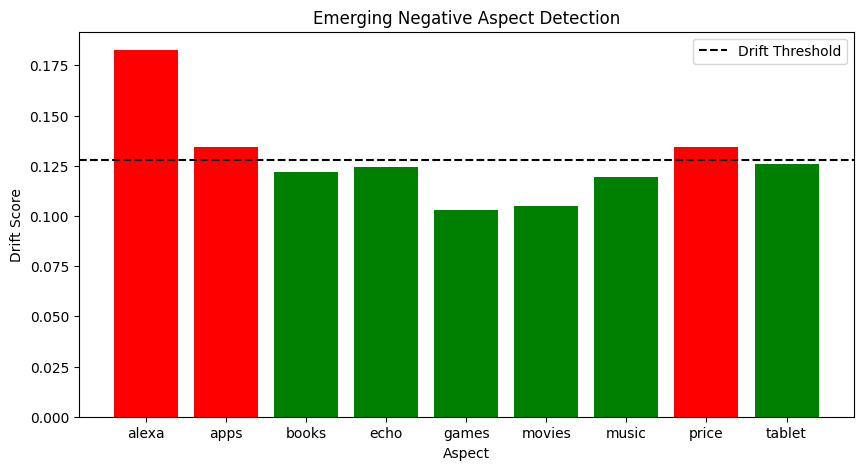

In [109]:
import matplotlib.pyplot as plt

colors = ["red" if s != "Stable" else "green" for s in drift_df["status"]]

plt.figure(figsize=(10,5))
plt.bar(drift_df["aspect"], drift_df["drift_score"], color=colors)

plt.axhline(threshold, color="black", linestyle="--", label="Drift Threshold")

plt.title("Emerging Negative Aspect Detection")
plt.xlabel("Aspect")
plt.ylabel("Drift Score")

plt.legend()
plt.show()

**PHASE 7**

In [110]:
X_baseline = X_text

In [111]:
from sklearn.model_selection import train_test_split

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_baseline, y, test_size=0.2, random_state=42
)

In [112]:
from sklearn.ensemble import RandomForestClassifier

baseline_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced"
)

baseline_model.fit(Xb_train, yb_train)

RandomForestClassifier(class_weight='balanced')

In [113]:
baseline_accuracy = baseline_model.score(Xb_test, yb_test)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.69


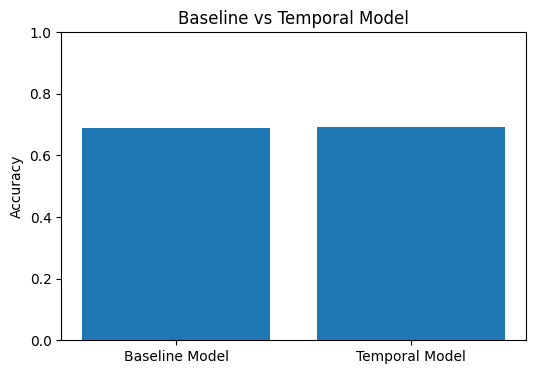

In [114]:
import matplotlib.pyplot as plt

models = ["Baseline Model", "Temporal Model"]
scores = [baseline_accuracy, accuracy]

plt.figure(figsize=(6,4))
plt.bar(models, scores)

plt.ylabel("Accuracy")
plt.title("Baseline vs Temporal Model")
plt.ylim(0,1)

plt.show()

**PHASE 8**

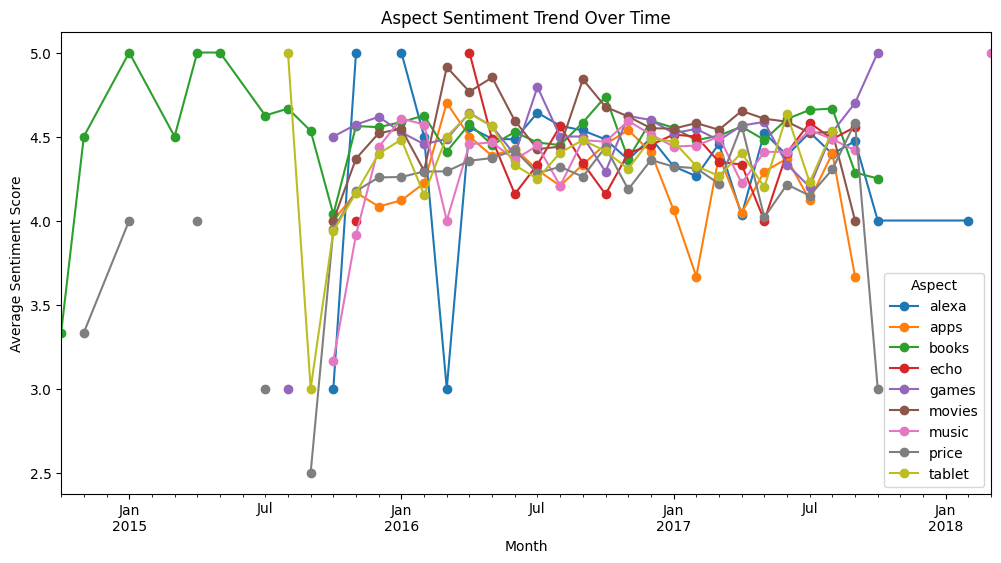

In [115]:
import matplotlib.pyplot as plt

pivot_table.plot(figsize=(12,6), marker='o')

plt.title("Aspect Sentiment Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Average Sentiment Score")
plt.legend(title="Aspect")

plt.show()

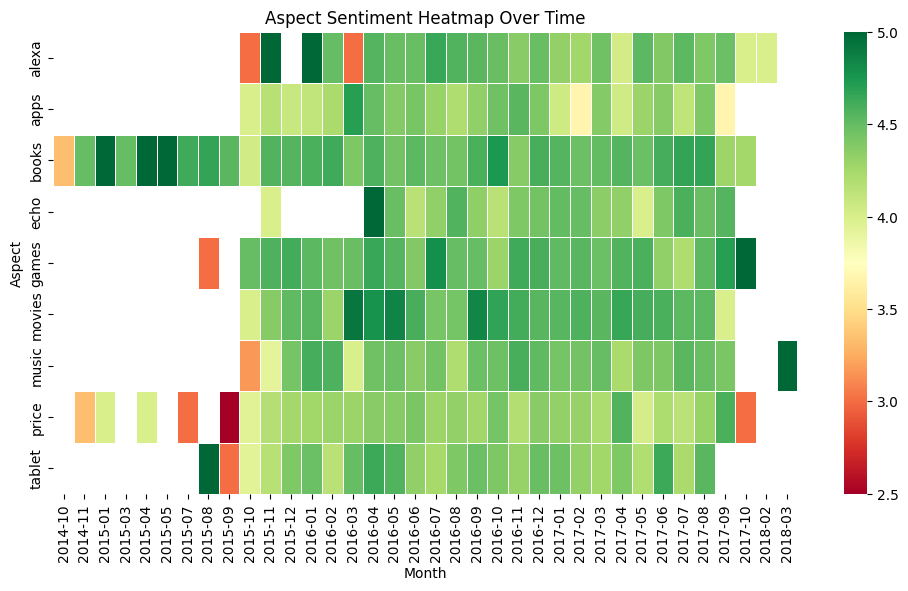

In [116]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot_table.T,
    cmap="RdYlGn",
    linewidths=0.5
)

plt.title("Aspect Sentiment Heatmap Over Time")
plt.xlabel("Month")
plt.ylabel("Aspect")

plt.show()

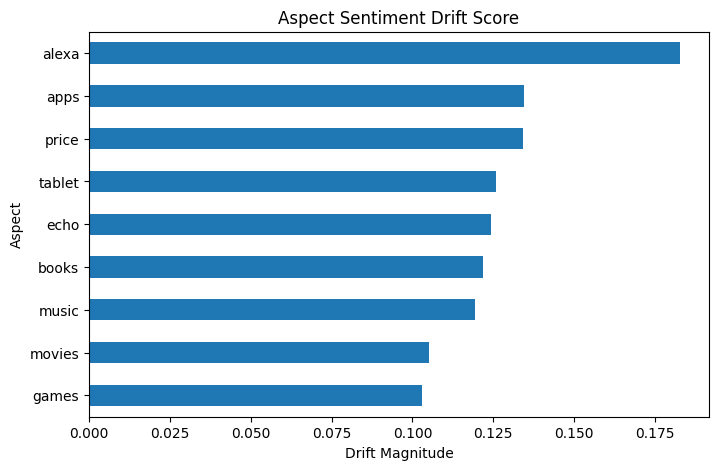

In [117]:
drift_score.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Aspect Sentiment Drift Score")
plt.xlabel("Drift Magnitude")
plt.ylabel("Aspect")

plt.show()

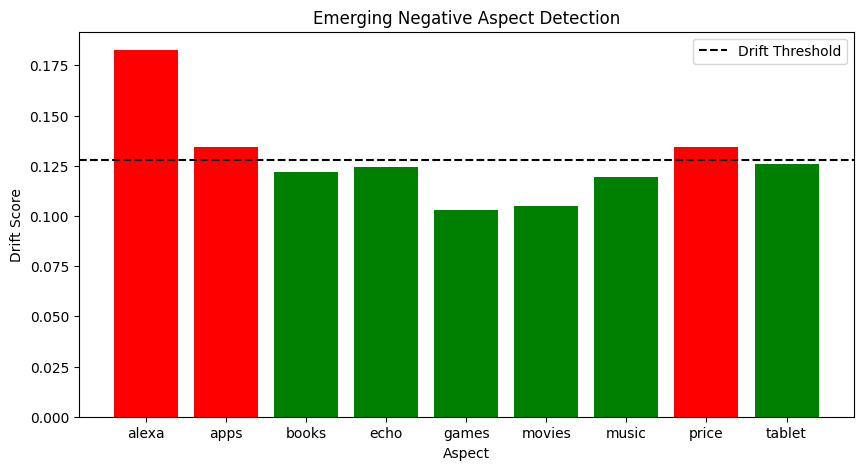

In [118]:
colors = ["red" if s != "Stable" else "green" for s in drift_df["status"]]

plt.figure(figsize=(10,5))

plt.bar(drift_df["aspect"], drift_df["drift_score"], color=colors)

plt.axhline(threshold, linestyle="--", color="black", label="Drift Threshold")

plt.title("Emerging Negative Aspect Detection")
plt.xlabel("Aspect")
plt.ylabel("Drift Score")

plt.legend()

plt.show()

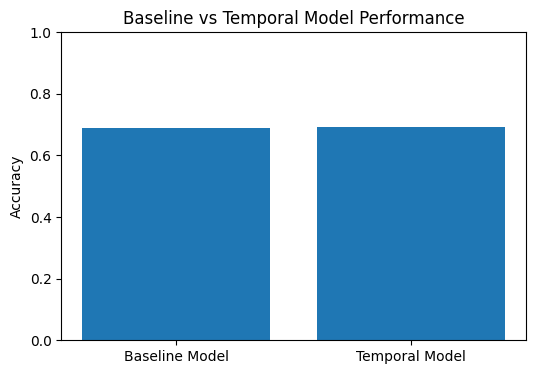

In [119]:
models = ["Baseline Model", "Temporal Model"]
scores = [baseline_accuracy, accuracy]

plt.figure(figsize=(6,4))

plt.bar(models, scores)

plt.ylabel("Accuracy")
plt.title("Baseline vs Temporal Model Performance")
plt.ylim(0,1)

plt.show()

***DASHBOARD***

In [121]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 89.3 MB/s eta 0:00:00


In [132]:
from google.colab import output
output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [133]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.87.49.182:8501

  Stopping...
  Stopping...


In [135]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.title("Temporal Aspect Sentiment Drift Dashboard")

st.write("Analysis of sentiment changes across product aspects over time.")

# Load data
pivot_table = pd.read_csv("pivot_aspect_sentiment_monthly.csv", index_col=0)
drift_df = pd.read_csv("drift_results.csv")

# Sentiment Trend
st.subheader("Aspect Sentiment Trend Over Time")

fig, ax = plt.subplots(figsize=(10,5))
pivot_table.plot(ax=ax)
st.pyplot(fig)

# Drift Score
st.subheader("Aspect Sentiment Drift Score")

fig2, ax2 = plt.subplots()
ax2.barh(drift_df["aspect"], drift_df["drift_score"])
ax2.set_xlabel("Drift Score")
st.pyplot(fig2)

# Emerging Aspects
st.subheader("Emerging Negative Aspects")

emerging = drift_df[drift_df["status"] != "Stable"]
st.dataframe(emerging)

Overwriting app.py


In [136]:
pivot_table.to_csv("pivot_aspect_sentiment_monthly.csv")

drift_df.to_csv("drift_results.csv")

In [137]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.87.49.182:8501

  Stopping...
  Stopping...
Exception ignored in: <module 'threading' from '/usr/lib/python3.12/threading.py'>
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1594, in _shutdown
    atexit_call()
  File "/usr/lib/python3.12/concurrent/futures/thread.py", line 31, in _python_exit
    t.join()
  File "/usr/lib/python3.12/threading.py", line 1149, in join
    self._wait_for_tstate_lock()
  File "/usr/lib/python3.12/threading.py", line 1169, in _wait_for_tstate_lock
    if lock.acquire(block, timeout):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/streamlit/web/bootstrap.py", line 43, in signal_handler
    server.stop()
  File "/usr/local/lib/python3.12/dist-packages/streamlit/web/server/server.py", line 540, in stop
    self._runtime.stop()
  Fi

In [138]:
!streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.87.49.182:8501

  Stopping...
^C


In [139]:
!pip install streamlit pyngrok

In [140]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.title("Temporal Aspect Sentiment Drift Dashboard")

pivot_table = pd.read_csv("pivot_aspect_sentiment_monthly.csv", index_col=0)
drift_df = pd.read_csv("drift_results.csv")

st.subheader("Aspect Sentiment Trend")
fig, ax = plt.subplots(figsize=(10,5))
pivot_table.plot(ax=ax)
st.pyplot(fig)

st.subheader("Aspect Drift Score")
fig2, ax2 = plt.subplots()
ax2.barh(drift_df["aspect"], drift_df["drift_score"])
st.pyplot(fig2)

st.subheader("Emerging Negative Aspects")
emerging = drift_df[drift_df["status"] != "Stable"]
st.dataframe(emerging)

Overwriting app.py


In [141]:
from pyngrok import ngrok
import subprocess

public_url = ngrok.connect(8501)
print("Open this URL:", public_url)

!streamlit run app.py &

ERROR:pyngrok.process.ngrok:t=2026-03-12T07:42:51+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-03-12T07:42:51+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-03-12T07:42:51+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.